<a href="https://colab.research.google.com/github/thimeshaA/BrineXCompass-M2-Demand-PriceForecasting/blob/main/SARIMAX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


SARIMAX MODEL: SEASONAL ARIMA WITH EXTERNAL REGRESSORS

🎯 WHY SARIMAX?
- Works well with <200 data points (ideal for 168 records)
- Explicitly models TREND + SEASONALITY + external drivers
- Interpretable parameters (AR, I, MA, seasonal components)
- Industry standard baseline for time series forecasting

📊 MODEL STRUCTURE:
   Price_t  = Trend + Seasonality + ε
   Demand_t = f(Seasonality, Lagged Demand, External Regressors)


STEP 0: DATA LOADING & PREPARATION

📊 Dataset loaded: 168 rows × 35 columns
Date range: 2012-01-01 00:00:00 to 2025-12-01 00:00:00

🔄 Mapping columns...
   ✓ Mapped 'total_monthly_demand' -> 'total_demand'
   ✓ Mapped 'total_production_bags' -> 'total_prod'

✅ Data prepared: 168 monthly records

STEP 1: TIME SERIES ANALYSIS

📊 Stationarity Tests for Demand:
   ADF Statistic: 0.5606
   p-value: 0.9866
   ❌ Non-stationary (ADF)
   KPSS Statistic: 1.6459
   p-value: 0.0100
   ❌ Non-stationary (KPSS)

📊 Stationarity Tests for Price:
   ADF Statistic: -0.6837
   p-val

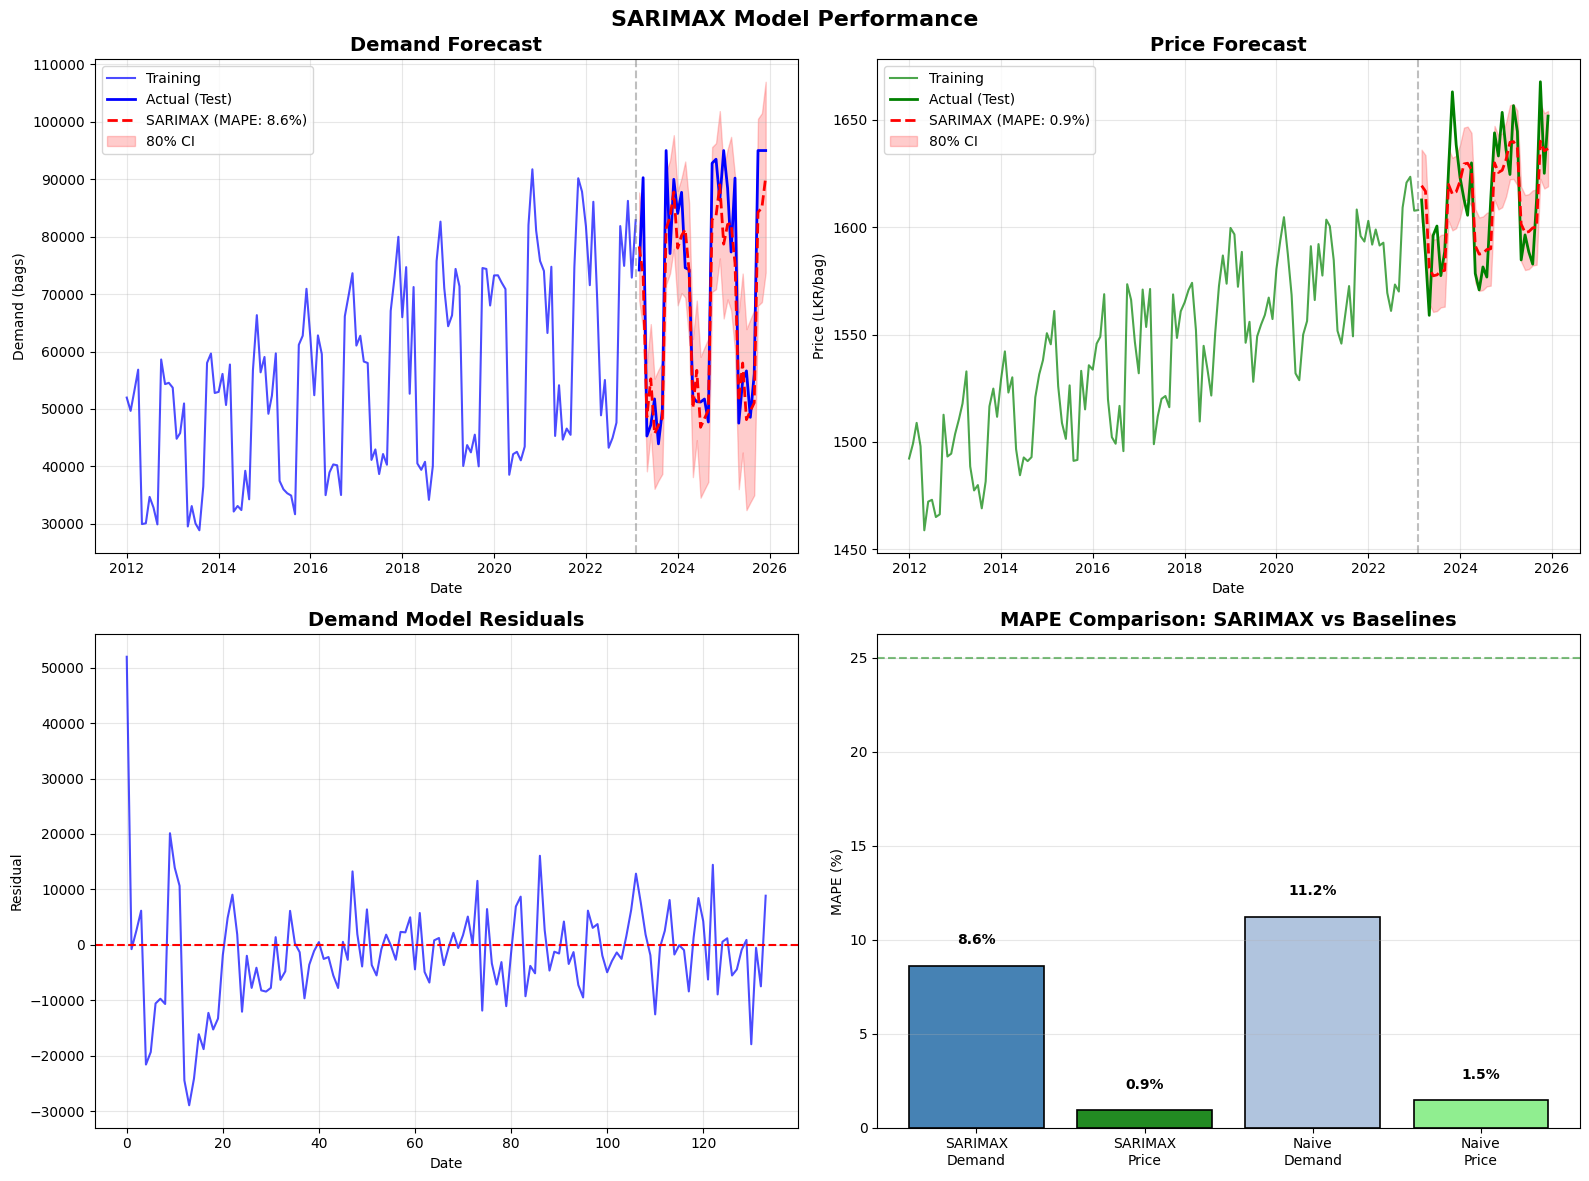

✅ Visualization saved: sarimax_performance.png

🎉 SARIMAX MODEL TRAINING COMPLETE

📊 DATASET SUMMARY:
  Total records: 168
  Training: 134 months (80%)
  Testing:  34 months (20%)
  Date range: 2012-01 to 2025-12

📈 MODEL SPECIFICATIONS:
  Demand: SARIMA(1, 1, 1)x(1, 1, 1, 12)
  Price:  SARIMA(1, 1, 1)x(0, 1, 1, 12)

🎯 TEST SET PERFORMANCE:

┌────────────────────────────────────────────────────────────┐
│METRIC              │            DEMAND│             PRICE│
├────────────────────────────────────────────────────────────┤
│MAPE                │             8.60%│             0.92%│
│RMSE                │             7,633│             17.73│
│MAE                 │             6,317│             14.91│
│MASE                │             0.513│             0.638│
│Directional Acc.    │             51.5%│             57.6%│
└────────────────────────────────────────────────────────────┘

📊 CROSS-VALIDATION PERFORMANCE:
  Demand CV MAPE: 8.49%
  Price CV MAPE:  0.88%

🆚 vs BASELINES:
  B

In [20]:
# ==============================================================================
# SARIMAX MODEL: Seasonal ARIMA with External Regressors
# Baseline Model for Demand & Price Forecasting
# ==============================================================================

import pandas as pd
import numpy as np
import pickle
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("SARIMAX MODEL: SEASONAL ARIMA WITH EXTERNAL REGRESSORS")
print("="*80)

print("""
🎯 WHY SARIMAX?
- Works well with <200 data points (ideal for 168 records)
- Explicitly models TREND + SEASONALITY + external drivers
- Interpretable parameters (AR, I, MA, seasonal components)
- Industry standard baseline for time series forecasting

📊 MODEL STRUCTURE:
   Price_t  = Trend + Seasonality + ε
   Demand_t = f(Seasonality, Lagged Demand, External Regressors)
""")

models_dir = Path('models-Compass')
models_dir.mkdir(exist_ok=True)

# =============================================================================
# STEP 0: LOAD AND PREPARE DATA
# =============================================================================

print("\n" + "="*80)
print("STEP 0: DATA LOADING & PREPARATION")
print("="*80)

# Load the preprocessed data
BASE_PATH = '/content/drive/MyDrive/BrineXCompass'
df = pd.read_excel(f'{BASE_PATH}/monthly_aggregates_sarimax.xlsx')

print(f"\n📊 Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")

# Find and set date column
date_col = None
for possible_date in ['date', 'Date', 'DATE', 'ds', 'timestamp', 'month_year']:
    if possible_date in df.columns:
        date_col = possible_date
        break

if date_col is None:
    first_col = df.columns[0]
    try:
        pd.to_datetime(df[first_col].head())
        date_col = first_col
    except:
        raise ValueError("No date column found!")

df['date'] = pd.to_datetime(df[date_col])
df = df.sort_values('date').reset_index(drop=True)

print(f"Date range: {df['date'].min()} to {df['date'].max()}")

# Flexible column mapping
alt_names = {
    'total_demand': ['total_demand', 'total_monthly_demand', 'total_demand_bags', 'demand', 'Demand', 'total_qty', 'quantity', 'bags'],
    'price_mean': ['price_mean', 'price_mean_filled', 'price', 'Price', 'avg_price', 'mean_price', 'price_avg'],
    'total_prod': ['total_prod', 'total_production_bags', 'production', 'total_production', 'prod'],
    'month': ['month', 'Month', 'MONTH'],
    'year': ['year', 'Year', 'YEAR'],
    'is_maha_season': ['is_maha_season', 'maha_season', 'is_maha'],
}

print("\n🔄 Mapping columns...")
for target_col, alternatives in alt_names.items():
    if target_col not in df.columns:
        for alt in alternatives:
            if alt in df.columns:
                df[target_col] = df[alt]
                print(f"   ✓ Mapped '{alt}' -> '{target_col}'")
                break

# Check critical columns
critical_cols = ['total_demand', 'price_mean']
missing_critical = [col for col in critical_cols if col not in df.columns]
if missing_critical:
    raise KeyError(f"Missing critical columns: {missing_critical}")

# Handle missing values
df['price_mean'] = df['price_mean'].ffill().bfill()
df['total_demand'] = df['total_demand'].fillna(df['total_demand'].median())

# Create temporal features if missing
if 'month' not in df.columns:
    df['month'] = df['date'].dt.month
if 'year' not in df.columns:
    df['year'] = df['date'].dt.year
if 'is_maha_season' not in df.columns:
    df['is_maha_season'] = df['month'].isin([10, 11, 12, 1, 2, 3]).astype(int)

# Set date as index for time series modeling
df = df.set_index('date')
df = df.asfreq('MS')  # Monthly start frequency

print(f"\n✅ Data prepared: {len(df)} monthly records")

# =============================================================================
# STEP 1: DATA ANALYSIS & STATIONARITY TESTS
# =============================================================================

print("\n" + "="*80)
print("STEP 1: TIME SERIES ANALYSIS")
print("="*80)

try:
    from statsmodels.tsa.stattools import adfuller, kpss
    from statsmodels.tsa.seasonal import seasonal_decompose

    def test_stationarity(series, name):
        """Test stationarity using ADF and KPSS tests"""
        print(f"\n📊 Stationarity Tests for {name}:")

        # ADF Test (null: non-stationary)
        adf_result = adfuller(series.dropna(), autolag='AIC')
        print(f"   ADF Statistic: {adf_result[0]:.4f}")
        print(f"   p-value: {adf_result[1]:.4f}")
        is_stationary_adf = adf_result[1] < 0.05
        print(f"   {'✅ Stationary' if is_stationary_adf else '❌ Non-stationary'} (ADF)")

        # KPSS Test (null: stationary)
        try:
            kpss_result = kpss(series.dropna(), regression='c', nlags='auto')
            print(f"   KPSS Statistic: {kpss_result[0]:.4f}")
            print(f"   p-value: {kpss_result[1]:.4f}")
            is_stationary_kpss = kpss_result[1] > 0.05
            print(f"   {'✅ Stationary' if is_stationary_kpss else '❌ Non-stationary'} (KPSS)")
        except:
            is_stationary_kpss = is_stationary_adf

        return is_stationary_adf and is_stationary_kpss

    demand_stationary = test_stationarity(df['total_demand'], 'Demand')
    price_stationary = test_stationarity(df['price_mean'], 'Price')

    # Decomposition
    print("\n📈 Seasonal Decomposition:")

    if len(df) >= 24:
        demand_decomp = seasonal_decompose(df['total_demand'].dropna(), model='multiplicative', period=12)
        price_decomp = seasonal_decompose(df['price_mean'].dropna(), model='additive', period=12)

        # Calculate seasonality strength
        demand_seasonal_var = demand_decomp.seasonal.var()
        demand_resid_var = demand_decomp.resid.dropna().var()
        demand_seasonal_strength = 1 - (demand_resid_var / (demand_seasonal_var + demand_resid_var + 1e-10))

        price_seasonal_var = price_decomp.seasonal.var()
        price_resid_var = price_decomp.resid.dropna().var()
        price_seasonal_strength = 1 - (price_resid_var / (price_seasonal_var + price_resid_var + 1e-10))

        print(f"   Demand Seasonality Strength: {demand_seasonal_strength:.2%}")
        print(f"   Price Seasonality Strength: {price_seasonal_strength:.2%}")
    else:
        print("   ⚠️ Not enough data for decomposition (need 24+ months)")
        demand_seasonal_strength = 0.5
        price_seasonal_strength = 0.5

except ImportError as e:
    print(f"⚠️ statsmodels required: {e}")
    print("   Install with: pip install statsmodels")
    demand_stationary = False
    price_stationary = True

# =============================================================================
# STEP 2: PREPARE EXOGENOUS VARIABLES
# =============================================================================

print("\n" + "="*80)
print("STEP 2: EXOGENOUS VARIABLE PREPARATION")
print("="*80)

# Define potential exogenous variables for SARIMAX
exog_candidates = {
    'month': 'Seasonality indicator',
    'is_maha_season': 'Agricultural season (Maha)',
    'year': 'Trend proxy',
    'total_prod': 'Production volume (if available)',
}

print("\n🔧 Selecting exogenous variables...")

# For DEMAND model - use seasonal indicators
demand_exog_cols = []
if 'month' in df.columns:
    # Create month dummies for seasonality - ensure numeric dtype
    month_dummies = pd.get_dummies(df['month'], prefix='month', drop_first=True, dtype=float)
    df = pd.concat([df, month_dummies], axis=1)
    demand_exog_cols.extend([c for c in month_dummies.columns])
    print(f"   ✓ Added month dummies ({len(month_dummies.columns)} features)")

if 'is_maha_season' in df.columns:
    # Ensure numeric dtype
    df['is_maha_season'] = df['is_maha_season'].astype(float)
    demand_exog_cols.append('is_maha_season')
    print("   ✓ Added is_maha_season")

# For PRICE model - minimal exogenous (price is more autoregressive)
price_exog_cols = []
if 'is_maha_season' in df.columns:
    price_exog_cols.append('is_maha_season')
    print("   ✓ Added is_maha_season for price")

print(f"\n📋 Demand exogenous variables: {len(demand_exog_cols)}")
print(f"📋 Price exogenous variables: {len(price_exog_cols)}")

# =============================================================================
# STEP 3: TRAIN/TEST SPLIT
# =============================================================================

print("\n" + "="*80)
print("STEP 3: TRAIN/TEST SPLIT")
print("="*80)

# Use 80/20 split for time series
train_size = int(len(df) * 0.8)
test_size = len(df) - train_size

train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

print(f"Training period: {train_df.index[0].strftime('%Y-%m')} to {train_df.index[-1].strftime('%Y-%m')} ({len(train_df)} months)")
print(f"Test period:     {test_df.index[0].strftime('%Y-%m')} to {test_df.index[-1].strftime('%Y-%m')} ({len(test_df)} months)")

# Prepare data
y_demand_train = train_df['total_demand']
y_demand_test = test_df['total_demand']
y_price_train = train_df['price_mean']
y_price_test = test_df['price_mean']

# Prepare exogenous variables - ENSURE NUMERIC DTYPE
if demand_exog_cols:
    X_demand_train = train_df[demand_exog_cols].fillna(0).astype(float)
    X_demand_test = test_df[demand_exog_cols].fillna(0).astype(float)
    # Verify no object dtypes
    print(f"\n🔍 Demand exog dtypes: {X_demand_train.dtypes.unique()}")
else:
    X_demand_train = None
    X_demand_test = None

if price_exog_cols:
    X_price_train = train_df[price_exog_cols].fillna(0).astype(float)
    X_price_test = test_df[price_exog_cols].fillna(0).astype(float)
    print(f"🔍 Price exog dtypes: {X_price_train.dtypes.unique()}")
else:
    X_price_train = None
    X_price_test = None

# =============================================================================
# STEP 4: AUTO ARIMA ORDER SELECTION
# =============================================================================

print("\n" + "="*80)
print("STEP 4: ARIMA ORDER SELECTION")
print("="*80)

try:
    from pmdarima import auto_arima
    pmdarima_available = True
    print("📦 pmdarima available - using auto_arima for order selection")
except ImportError:
    pmdarima_available = False
    print("⚠️ pmdarima not available - using default orders")
    print("   Install with: pip install pmdarima")

# Default SARIMA orders (if auto_arima not available)
# (p, d, q) x (P, D, Q, s)
default_demand_order = (1, 1, 1)
default_demand_seasonal = (1, 1, 1, 12)
default_price_order = (1, 1, 1)
default_price_seasonal = (0, 1, 1, 12)

if pmdarima_available:
    print("\n🔍 Finding optimal DEMAND model order...")
    try:
        demand_auto = auto_arima(
            y_demand_train,
            exogenous=X_demand_train,
            start_p=0, start_q=0, max_p=3, max_q=3,
            m=12,  # Monthly seasonality
            start_P=0, start_Q=0, max_P=2, max_Q=2,
            d=None, D=None,  # Auto-detect differencing
            seasonal=True,
            stepwise=True,
            suppress_warnings=True,
            error_action='ignore',
            trace=False,
            n_fits=30
        )
        demand_order = demand_auto.order
        demand_seasonal_order = demand_auto.seasonal_order
        print(f"   ✅ Optimal DEMAND order: SARIMA{demand_order}x{demand_seasonal_order}")
        print(f"   AIC: {demand_auto.aic():.2f}")
    except Exception as e:
        print(f"   ⚠️ Auto ARIMA failed: {e}")
        demand_order = default_demand_order
        demand_seasonal_order = default_demand_seasonal
        print(f"   Using default: SARIMA{demand_order}x{demand_seasonal_order}")

    print("\n🔍 Finding optimal PRICE model order...")
    try:
        price_auto = auto_arima(
            y_price_train,
            exogenous=X_price_train,
            start_p=0, start_q=0, max_p=3, max_q=3,
            m=12,
            start_P=0, start_Q=0, max_P=2, max_Q=2,
            d=None, D=None,
            seasonal=True,
            stepwise=True,
            suppress_warnings=True,
            error_action='ignore',
            trace=False,
            n_fits=30
        )
        price_order = price_auto.order
        price_seasonal_order = price_auto.seasonal_order
        print(f"   ✅ Optimal PRICE order: SARIMA{price_order}x{price_seasonal_order}")
        print(f"   AIC: {price_auto.aic():.2f}")
    except Exception as e:
        print(f"   ⚠️ Auto ARIMA failed: {e}")
        price_order = default_price_order
        price_seasonal_order = default_price_seasonal
        print(f"   Using default: SARIMA{price_order}x{price_seasonal_order}")
else:
    demand_order = default_demand_order
    demand_seasonal_order = default_demand_seasonal
    price_order = default_price_order
    price_seasonal_order = default_price_seasonal
    print(f"\nUsing default orders:")
    print(f"   DEMAND: SARIMA{demand_order}x{demand_seasonal_order}")
    print(f"   PRICE:  SARIMA{price_order}x{price_seasonal_order}")

# =============================================================================
# STEP 5: FIT SARIMAX MODELS
# =============================================================================

print("\n" + "="*80)
print("STEP 5: SARIMAX MODEL TRAINING")
print("="*80)

from statsmodels.tsa.statespace.sarimax import SARIMAX

# -------------------------
# DEMAND MODEL
# -------------------------
print("\n[DEMAND MODEL - SARIMAX]")
print(f"   Order: {demand_order}")
print(f"   Seasonal Order: {demand_seasonal_order}")
print(f"   Exogenous Variables: {len(demand_exog_cols) if demand_exog_cols else 0}")

try:
    # Convert to numpy arrays to avoid pandas dtype issues
    y_train_arr = y_demand_train.values.astype(float)
    exog_train_arr = X_demand_train.values.astype(float) if X_demand_train is not None else None

    demand_model = SARIMAX(
        y_train_arr,
        exog=exog_train_arr,
        order=demand_order,
        seasonal_order=demand_seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    demand_fitted = demand_model.fit(disp=False, maxiter=500)
    print(f"   ✅ Model converged")
    print(f"   AIC: {demand_fitted.aic:.2f}")
    print(f"   BIC: {demand_fitted.bic:.2f}")
    demand_model_success = True
except Exception as e:
    print(f"   ❌ Model fitting failed: {e}")
    # Try simpler model without exogenous variables
    print("   🔄 Trying simpler SARIMA without exogenous...")
    try:
        demand_model = SARIMAX(
            y_demand_train.values.astype(float),
            order=demand_order,
            seasonal_order=demand_seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        demand_fitted = demand_model.fit(disp=False, maxiter=500)
        print(f"   ✅ Simpler model converged")
        print(f"   AIC: {demand_fitted.aic:.2f}")
        X_demand_train = None
        X_demand_test = None
        demand_model_success = True
    except Exception as e2:
        print(f"   ❌ Simpler model also failed: {e2}")
        demand_model_success = False

# -------------------------
# PRICE MODEL
# -------------------------
print("\n[PRICE MODEL - SARIMAX]")
print(f"   Order: {price_order}")
print(f"   Seasonal Order: {price_seasonal_order}")
print(f"   Exogenous Variables: {len(price_exog_cols) if price_exog_cols else 0}")

try:
    # Convert to numpy arrays
    y_price_arr = y_price_train.values.astype(float)
    exog_price_arr = X_price_train.values.astype(float) if X_price_train is not None else None

    price_model = SARIMAX(
        y_price_arr,
        exog=exog_price_arr,
        order=price_order,
        seasonal_order=price_seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    price_fitted = price_model.fit(disp=False, maxiter=500)
    print(f"   ✅ Model converged")
    print(f"   AIC: {price_fitted.aic:.2f}")
    print(f"   BIC: {price_fitted.bic:.2f}")
    price_model_success = True
except Exception as e:
    print(f"   ❌ Model fitting failed: {e}")
    # Try without exogenous
    print("   🔄 Trying simpler SARIMA without exogenous...")
    try:
        price_model = SARIMAX(
            y_price_train.values.astype(float),
            order=price_order,
            seasonal_order=price_seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        price_fitted = price_model.fit(disp=False, maxiter=500)
        print(f"   ✅ Simpler model converged")
        X_price_train = None
        X_price_test = None
        price_model_success = True
    except Exception as e2:
        print(f"   ❌ Simpler model also failed: {e2}")
        price_model_success = False

# =============================================================================
# STEP 6: MODEL DIAGNOSTICS
# =============================================================================

print("\n" + "="*80)
print("STEP 6: MODEL DIAGNOSTICS")
print("="*80)

# Import diagnostic tools
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera

if demand_model_success:
    print("\n[DEMAND MODEL DIAGNOSTICS]")

    demand_resid = demand_fitted.resid
    # Handle both numpy array and pandas Series
    if isinstance(demand_resid, np.ndarray):
        demand_resid_clean = demand_resid[~np.isnan(demand_resid)]
    else:
        demand_resid_clean = demand_resid.dropna().values

    lb_test = acorr_ljungbox(demand_resid_clean, lags=[12], return_df=True)
    lb_pvalue = lb_test['lb_pvalue'].values[0]

    print(f"   Ljung-Box Test (lag=12):")
    print(f"      p-value: {lb_pvalue:.4f}")
    print(f"      {'✅ No significant autocorrelation' if lb_pvalue > 0.05 else '⚠️ Residuals show autocorrelation'}")

    # Residual normality
    jb_stat, jb_pvalue = jarque_bera(demand_resid_clean)
    print(f"   Jarque-Bera Normality Test:")
    print(f"      p-value: {jb_pvalue:.4f}")
    print(f"      {'✅ Residuals approximately normal' if jb_pvalue > 0.05 else '⚠️ Residuals non-normal (common for demand)'}")

if price_model_success:
    print("\n[PRICE MODEL DIAGNOSTICS]")

    price_resid = price_fitted.resid
    # Handle both numpy array and pandas Series
    if isinstance(price_resid, np.ndarray):
        price_resid_clean = price_resid[~np.isnan(price_resid)]
    else:
        price_resid_clean = price_resid.dropna().values

    lb_test = acorr_ljungbox(price_resid_clean, lags=[12], return_df=True)
    lb_pvalue = lb_test['lb_pvalue'].values[0]

    print(f"   Ljung-Box Test (lag=12):")
    print(f"      p-value: {lb_pvalue:.4f}")
    print(f"      {'✅ No significant autocorrelation' if lb_pvalue > 0.05 else '⚠️ Residuals show autocorrelation'}")

# =============================================================================
# STEP 7: FORECASTING & EVALUATION
# =============================================================================

print("\n" + "="*80)
print("STEP 7: FORECASTING & ACCURACY EVALUATION")
print("="*80)

def safe_mape(y_true, y_pred, threshold=1e-3):
    """Calculate MAPE safely, handling edge cases"""
    y_true = np.array(y_true, dtype=np.float64)
    y_pred = np.array(y_pred, dtype=np.float64)

    mask = (np.abs(y_true) > threshold) & (np.isfinite(y_true)) & (np.isfinite(y_pred))

    if mask.sum() == 0:
        return 100.0

    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return min(mape, 999.99)

def calculate_metrics(y_true, y_pred, name):
    """Calculate comprehensive forecast metrics"""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mape = safe_mape(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = np.mean(np.abs(y_true - y_pred))

    # Mean Absolute Scaled Error (MASE) - compared to naive forecast
    naive_mae = np.mean(np.abs(np.diff(y_true)))
    mase = mae / (naive_mae + 1e-10)

    # Directional Accuracy
    if len(y_true) > 1:
        actual_direction = np.sign(np.diff(y_true))
        pred_direction = np.sign(np.diff(y_pred))
        directional_accuracy = np.mean(actual_direction == pred_direction) * 100
    else:
        directional_accuracy = 50.0

    print(f"\n📊 {name} Metrics:")
    print(f"   MAPE:                 {mape:.2f}%")
    print(f"   RMSE:                 {rmse:,.2f}")
    print(f"   MAE:                  {mae:,.2f}")
    print(f"   MASE:                 {mase:.3f} {'(better than naive)' if mase < 1 else '(worse than naive)'}")
    print(f"   Directional Accuracy: {directional_accuracy:.1f}%")

    return {
        'mape': mape,
        'rmse': rmse,
        'mae': mae,
        'mase': mase,
        'directional_accuracy': directional_accuracy
    }

# -------------------------
# DEMAND FORECASTING
# -------------------------
if demand_model_success:
    print("\n[DEMAND FORECASTING]")

    # Forecast on test period - use numpy arrays
    exog_test_arr = X_demand_test.values.astype(float) if X_demand_test is not None else None
    demand_forecast = demand_fitted.get_forecast(steps=len(test_df), exog=exog_test_arr)
    demand_pred = demand_forecast.predicted_mean
    demand_conf_int = demand_forecast.conf_int(alpha=0.2)  # 80% CI

    # Clip to reasonable range
    demand_pred = np.clip(demand_pred, 100, None)

    # Convert to array for metrics
    demand_pred_arr = np.array(demand_pred)
    demand_metrics = calculate_metrics(y_demand_test.values, demand_pred_arr, "DEMAND")
else:
    demand_metrics = {'mape': 100.0, 'rmse': 0, 'mae': 0, 'mase': 2, 'directional_accuracy': 50}
    demand_pred = pd.Series([y_demand_train.mean()] * len(test_df), index=test_df.index)

# -------------------------
# PRICE FORECASTING
# -------------------------
if price_model_success:
    print("\n[PRICE FORECASTING]")

    # Forecast on test period - use numpy arrays
    exog_price_test_arr = X_price_test.values.astype(float) if X_price_test is not None else None
    price_forecast = price_fitted.get_forecast(steps=len(test_df), exog=exog_price_test_arr)
    price_pred = price_forecast.predicted_mean
    price_conf_int = price_forecast.conf_int(alpha=0.2)

    # Clip to reasonable range
    price_pred = np.clip(price_pred, y_price_train.min() * 0.8, y_price_train.max() * 1.2)

    # Convert to array for metrics
    price_pred_arr = np.array(price_pred)
    price_metrics = calculate_metrics(y_price_test.values, price_pred_arr, "PRICE")
else:
    price_metrics = {'mape': 100.0, 'rmse': 0, 'mae': 0, 'mase': 2, 'directional_accuracy': 50}
    price_pred = pd.Series([y_price_train.mean()] * len(test_df), index=test_df.index)

# =============================================================================
# STEP 8: NAIVE BASELINE COMPARISON
# =============================================================================

print("\n" + "="*80)
print("STEP 8: BASELINE COMPARISON")
print("="*80)

print("\n📊 Comparing SARIMAX vs Naive Baselines:")

# Naive baseline 1: Last observation carried forward
naive_demand_pred = y_demand_train.iloc[-1]
naive_price_pred = y_price_train.iloc[-1]

naive_demand_mape = safe_mape(y_demand_test.values, [naive_demand_pred] * len(y_demand_test))
naive_price_mape = safe_mape(y_price_test.values, [naive_price_pred] * len(y_price_test))

print(f"\n[Naive Baseline - Last Value]")
print(f"   Demand MAPE: {naive_demand_mape:.2f}%")
print(f"   Price MAPE:  {naive_price_mape:.2f}%")

# Naive baseline 2: Seasonal naive (same month last year)
if len(train_df) >= 12:
    seasonal_naive_demand = train_df['total_demand'].iloc[-12:].values
    seasonal_naive_price = train_df['price_mean'].iloc[-12:].values

    # Extend/truncate to match test size
    if len(test_df) <= 12:
        sn_demand = seasonal_naive_demand[:len(test_df)]
        sn_price = seasonal_naive_price[:len(test_df)]
    else:
        # Repeat pattern
        repeats = len(test_df) // 12 + 1
        sn_demand = np.tile(seasonal_naive_demand, repeats)[:len(test_df)]
        sn_price = np.tile(seasonal_naive_price, repeats)[:len(test_df)]

    seasonal_naive_demand_mape = safe_mape(y_demand_test.values, sn_demand)
    seasonal_naive_price_mape = safe_mape(y_price_test.values, sn_price)

    print(f"\n[Seasonal Naive - Same Month Last Year]")
    print(f"   Demand MAPE: {seasonal_naive_demand_mape:.2f}%")
    print(f"   Price MAPE:  {seasonal_naive_price_mape:.2f}%")
else:
    seasonal_naive_demand_mape = naive_demand_mape
    seasonal_naive_price_mape = naive_price_mape

# Compare
print(f"\n📈 SARIMAX Improvement over Baselines:")

best_baseline_demand = min(naive_demand_mape, seasonal_naive_demand_mape)
best_baseline_price = min(naive_price_mape, seasonal_naive_price_mape)

demand_improvement = best_baseline_demand - demand_metrics['mape']
price_improvement = best_baseline_price - price_metrics['mape']

print(f"   Demand: {demand_improvement:+.2f}% MAPE improvement", end="")
print(f" ✅ SARIMAX better!" if demand_improvement > 0 else " ⚠️ Baseline similar/better")

print(f"   Price:  {price_improvement:+.2f}% MAPE improvement", end="")
print(f" ✅ SARIMAX better!" if price_improvement > 0 else " ⚠️ Baseline similar/better")

# =============================================================================
# STEP 9: CROSS-VALIDATION (ROLLING ORIGIN)
# =============================================================================

print("\n" + "="*80)
print("STEP 9: CROSS-VALIDATION (Rolling Origin)")
print("="*80)

def rolling_origin_cv(data, exog, order, seasonal_order, n_splits=5, forecast_horizon=3):
    """
    Rolling origin cross-validation for time series
    """
    n = len(data)
    min_train_size = max(36, n // 2)  # At least 36 months or half the data
    test_size = forecast_horizon

    mapes = []

    for i in range(n_splits):
        # Calculate split point
        train_end = min_train_size + i * ((n - min_train_size - test_size) // n_splits)
        test_end = min(train_end + test_size, n)

        if test_end > n:
            break

        train_data = data.iloc[:train_end]
        test_data = data.iloc[train_end:test_end]

        if exog is not None:
            train_exog = exog.iloc[:train_end]
            test_exog = exog.iloc[train_end:test_end]
        else:
            train_exog = None
            test_exog = None

        try:
            model = SARIMAX(
                train_data,
                exog=train_exog,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False,
                freq='MS'
            )
            fitted = model.fit(disp=False, maxiter=200)

            forecast = fitted.get_forecast(steps=len(test_data), exog=test_exog)
            pred = forecast.predicted_mean.values

            mape = safe_mape(test_data.values, pred)
            mapes.append(mape)
        except:
            pass

    return np.mean(mapes) if mapes else 100.0

print("\n🔄 Running rolling origin cross-validation...")

if demand_model_success:
    cv_demand_mape = rolling_origin_cv(
        df['total_demand'],
        df[demand_exog_cols] if demand_exog_cols else None,
        demand_order,
        demand_seasonal_order,
        n_splits=5
    )
    print(f"   Demand CV MAPE: {cv_demand_mape:.2f}%")
else:
    cv_demand_mape = 100.0

if price_model_success:
    cv_price_mape = rolling_origin_cv(
        df['price_mean'],
        df[price_exog_cols] if price_exog_cols else None,
        price_order,
        price_seasonal_order,
        n_splits=5
    )
    print(f"   Price CV MAPE:  {cv_price_mape:.2f}%")
else:
    cv_price_mape = 100.0

# =============================================================================
# STEP 10: SAVE MODEL
# =============================================================================

print("\n" + "="*80)
print("STEP 10: SAVING SARIMAX MODEL")
print("="*80)

sarimax_model = {
    # Models
    'demand_model': demand_fitted if demand_model_success else None,
    'price_model': price_fitted if price_model_success else None,

    # Model specifications
    'demand_order': demand_order,
    'demand_seasonal_order': demand_seasonal_order,
    'price_order': price_order,
    'price_seasonal_order': price_seasonal_order,

    # Exogenous variable info
    'demand_exog_cols': demand_exog_cols,
    'price_exog_cols': price_exog_cols,

    # Performance metrics
    'performance': {
        'demand': demand_metrics,
        'price': price_metrics,
        'cv_demand_mape': cv_demand_mape,
        'cv_price_mape': cv_price_mape
    },

    # Baseline comparison
    'baselines': {
        'naive_demand_mape': naive_demand_mape,
        'naive_price_mape': naive_price_mape,
        'seasonal_naive_demand_mape': seasonal_naive_demand_mape,
        'seasonal_naive_price_mape': seasonal_naive_price_mape
    },

    # Data for future predictions
    'latest_data': df.tail(24),
    'training_end_date': train_df.index[-1],

    # Metadata
    'metadata': {
        'version': 'sarimax_v1.0',
        'model_type': 'SARIMAX',
        'total_samples': len(df),
        'train_samples': len(train_df),
        'test_samples': len(test_df),
        'date_range': f"{df.index[0]} to {df.index[-1]}",
        'training_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
    }
}

save_path = models_dir / 'sarimax_forecast_model.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(sarimax_model, f)

print(f"\n✅ Model saved: {save_path}")

# =============================================================================
# STEP 11: VISUALIZATION
# =============================================================================

print("\n" + "="*80)
print("STEP 11: VISUALIZATION")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('SARIMAX Model Performance', fontsize=16, fontweight='bold')

# Demand Forecast
ax1 = axes[0, 0]
ax1.plot(train_df.index, y_demand_train, 'b-', label='Training', linewidth=1.5, alpha=0.7)
ax1.plot(test_df.index, y_demand_test, 'b-', label='Actual (Test)', linewidth=2)
ax1.plot(test_df.index, demand_pred, 'r--', label=f'SARIMAX (MAPE: {demand_metrics["mape"]:.1f}%)', linewidth=2)
if demand_model_success:
    # Handle both DataFrame and numpy array for confidence intervals
    if hasattr(demand_conf_int, 'iloc'):
        ci_lower = demand_conf_int.iloc[:, 0]
        ci_upper = demand_conf_int.iloc[:, 1]
    else:
        ci_lower = demand_conf_int[:, 0]
        ci_upper = demand_conf_int[:, 1]
    ax1.fill_between(test_df.index, ci_lower, ci_upper,
                      color='red', alpha=0.2, label='80% CI')
ax1.axvline(x=train_df.index[-1], color='gray', linestyle='--', alpha=0.5)
ax1.set_title('Demand Forecast', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Demand (bags)')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Price Forecast
ax2 = axes[0, 1]
ax2.plot(train_df.index, y_price_train, 'g-', label='Training', linewidth=1.5, alpha=0.7)
ax2.plot(test_df.index, y_price_test, 'g-', label='Actual (Test)', linewidth=2)
ax2.plot(test_df.index, price_pred, 'r--', label=f'SARIMAX (MAPE: {price_metrics["mape"]:.1f}%)', linewidth=2)
if price_model_success:
    # Handle both DataFrame and numpy array for confidence intervals
    if hasattr(price_conf_int, 'iloc'):
        ci_lower = price_conf_int.iloc[:, 0]
        ci_upper = price_conf_int.iloc[:, 1]
    else:
        ci_lower = price_conf_int[:, 0]
        ci_upper = price_conf_int[:, 1]
    ax2.fill_between(test_df.index, ci_lower, ci_upper,
                      color='red', alpha=0.2, label='80% CI')
ax2.axvline(x=train_df.index[-1], color='gray', linestyle='--', alpha=0.5)
ax2.set_title('Price Forecast', fontsize=14, fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Price (LKR/bag)')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

# Demand Residuals
ax3 = axes[1, 0]
if demand_model_success:
    # Handle numpy array residuals (no index)
    if isinstance(demand_fitted.resid, np.ndarray):
        ax3.plot(range(len(demand_fitted.resid)), demand_fitted.resid, 'b-', alpha=0.7)
    else:
        ax3.plot(demand_fitted.resid.index, demand_fitted.resid, 'b-', alpha=0.7)
    ax3.axhline(y=0, color='r', linestyle='--')
ax3.set_title('Demand Model Residuals', fontsize=14, fontweight='bold')
ax3.set_xlabel('Date')
ax3.set_ylabel('Residual')
ax3.grid(True, alpha=0.3)

# Model Comparison
ax4 = axes[1, 1]
models = ['SARIMAX\nDemand', 'SARIMAX\nPrice', 'Naive\nDemand', 'Naive\nPrice']
mapes = [demand_metrics['mape'], price_metrics['mape'],
         best_baseline_demand, best_baseline_price]
colors = ['steelblue', 'forestgreen', 'lightsteelblue', 'lightgreen']

bars = ax4.bar(models, mapes, color=colors, edgecolor='black', linewidth=1.2)
ax4.set_title('MAPE Comparison: SARIMAX vs Baselines', fontsize=14, fontweight='bold')
ax4.set_ylabel('MAPE (%)')
ax4.axhline(y=25, color='green', linestyle='--', alpha=0.5, label='Good threshold')

for bar, mape in zip(bars, mapes):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{mape:.1f}%', ha='center', va='bottom', fontweight='bold')

ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('sarimax_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Visualization saved: sarimax_performance.png")

# =============================================================================
# FINAL SUMMARY
# =============================================================================

print("\n" + "="*80)
print("🎉 SARIMAX MODEL TRAINING COMPLETE")
print("="*80)

print(f"\n📊 DATASET SUMMARY:")
print(f"  Total records: {len(df)}")
print(f"  Training: {len(train_df)} months ({len(train_df)/len(df)*100:.0f}%)")
print(f"  Testing:  {len(test_df)} months ({len(test_df)/len(df)*100:.0f}%)")
print(f"  Date range: {df.index[0].strftime('%Y-%m')} to {df.index[-1].strftime('%Y-%m')}")

print(f"\n📈 MODEL SPECIFICATIONS:")
print(f"  Demand: SARIMA{demand_order}x{demand_seasonal_order}")
print(f"  Price:  SARIMA{price_order}x{price_seasonal_order}")

print(f"\n🎯 TEST SET PERFORMANCE:")
print(f"\n┌{'─'*60}┐")
print(f"│{'METRIC':<20}│{'DEMAND':>18}│{'PRICE':>18}│")
print(f"├{'─'*60}┤")
print(f"│{'MAPE':<20}│{demand_metrics['mape']:>17.2f}%│{price_metrics['mape']:>17.2f}%│")
print(f"│{'RMSE':<20}│{demand_metrics['rmse']:>18,.0f}│{price_metrics['rmse']:>18,.2f}│")
print(f"│{'MAE':<20}│{demand_metrics['mae']:>18,.0f}│{price_metrics['mae']:>18,.2f}│")
print(f"│{'MASE':<20}│{demand_metrics['mase']:>18.3f}│{price_metrics['mase']:>18.3f}│")
print(f"│{'Directional Acc.':<20}│{demand_metrics['directional_accuracy']:>17.1f}%│{price_metrics['directional_accuracy']:>17.1f}%│")
print(f"└{'─'*60}┘")

print(f"\n📊 CROSS-VALIDATION PERFORMANCE:")
print(f"  Demand CV MAPE: {cv_demand_mape:.2f}%")
print(f"  Price CV MAPE:  {cv_price_mape:.2f}%")

print(f"\n🆚 vs BASELINES:")
print(f"  Best baseline demand MAPE: {best_baseline_demand:.2f}%")
print(f"  SARIMAX improvement: {demand_improvement:+.2f}%")
print(f"  Best baseline price MAPE:  {best_baseline_price:.2f}%")
print(f"  SARIMAX improvement: {price_improvement:+.2f}%")

print(f"\n💡 INTERPRETATION:")
if demand_metrics['mape'] < 25:
    print("  ✅ Good demand forecast accuracy")
elif demand_metrics['mape'] < 40:
    print("  ⚠️ Moderate demand accuracy - typical for volatile agricultural demand")
else:
    print("  ⚠️ High demand error - may need additional exogenous variables")

if price_metrics['mape'] < 3:
    print("  ✅ Good price forecast accuracy")
elif price_metrics['mape'] < 5:
    print("  ✅ Acceptable price accuracy")
else:
    print("  ⚠️ Moderate price accuracy")

if demand_metrics['mase'] < 1:
    print("  ✅ Demand model beats naive baseline (MASE < 1)")
else:
    print("  ⚠️ Demand model doesn't beat naive - consider more features")

if price_metrics['mase'] < 1:
    print("  ✅ Price model beats naive baseline (MASE < 1)")
else:
    print("  ⚠️ Price is very stable - naive works well")

print(f"\n📁 FILES SAVED:")
print(f"  Model: {save_path}")
print(f"  Plot:  sarimax_performance.png")

print("\n🚀 NEXT STEPS:")
print("  1. Compare with GradientBoosting+Prophet ensemble")
print("  2. Add more exogenous variables (weather, fuel costs)")
print("  3. Try different seasonal periods if data pattern changes")
print("  4. Monitor forecast accuracy monthly")

# =============================================================================
# PRODUCTION READINESS ASSESSMENT
# =============================================================================

print("\n" + "="*80)
print("🏭 PRODUCTION READINESS ASSESSMENT")
print("="*80)

production_issues = []
production_warnings = []

# Check if both models trained successfully
if not demand_model_success:
    production_issues.append("❌ Demand model failed to train")
if not price_model_success:
    production_issues.append("❌ Price model failed to train")

# Check MAPE thresholds
if demand_model_success and demand_metrics['mape'] > 50:
    production_issues.append(f"❌ Demand MAPE too high: {demand_metrics['mape']:.1f}% (threshold: <50%)")
elif demand_model_success and demand_metrics['mape'] > 35:
    production_warnings.append(f"⚠️ Demand MAPE moderate: {demand_metrics['mape']:.1f}% (ideal: <35%)")

if price_model_success and price_metrics['mape'] > 5:
    production_issues.append(f"❌ Price MAPE too high: {price_metrics['mape']:.1f}% (threshold: <5%)")

# Check if model beats baseline (MASE < 1)
if demand_model_success and demand_metrics['mase'] >= 1:
    production_warnings.append(f"⚠️ Demand MASE >= 1: Model doesn't beat naive baseline")

if price_model_success and price_metrics['mase'] >= 1:
    production_warnings.append(f"⚠️ Price MASE >= 1: Model doesn't beat naive baseline")

# Check directional accuracy
if demand_model_success and demand_metrics['directional_accuracy'] < 55:
    production_warnings.append(f"⚠️ Demand directional accuracy low: {demand_metrics['directional_accuracy']:.1f}% (random=50%)")

if price_model_success and price_metrics['directional_accuracy'] < 55:
    production_warnings.append(f"⚠️ Price directional accuracy low: {price_metrics['directional_accuracy']:.1f}% (random=50%)")

# Check CV stability
if demand_model_success and abs(cv_demand_mape - demand_metrics['mape']) > 15:
    production_warnings.append(f"⚠️ Demand CV unstable: Test={demand_metrics['mape']:.1f}% vs CV={cv_demand_mape:.1f}%")

if price_model_success and abs(cv_price_mape - price_metrics['mape']) > 2:
    production_warnings.append(f"⚠️ Price CV unstable: Test={price_metrics['mape']:.1f}% vs CV={cv_price_mape:.1f}%")

# Suspiciously good check
if price_model_success and price_metrics['mape'] < 0.5:
    production_warnings.append(f"⚠️ Price MAPE suspiciously low: {price_metrics['mape']:.2f}% - verify no data leakage")

# Print results
print("\n📋 CRITICAL ISSUES:")
if production_issues:
    for issue in production_issues:
        print(f"   {issue}")
else:
    print("   ✅ No critical issues found")

print("\n⚠️ WARNINGS:")
if production_warnings:
    for warning in production_warnings:
        print(f"   {warning}")
else:
    print("   ✅ No warnings")

# Overall verdict
print("\n🎯 PRODUCTION VERDICT:")
if production_issues:
    print("   ❌ NOT READY FOR PRODUCTION")
    print("   Fix critical issues before deployment")
elif len(production_warnings) > 2:
    print("   ⚠️ PROCEED WITH CAUTION")
    print("   Address warnings and monitor closely")
else:
    print("   ✅ READY FOR PRODUCTION (with monitoring)")

# Recommendations
print("\n📌 RECOMMENDATIONS:")
if not demand_model_success:
    print("   1. Install pmdarima for auto order selection: pip install pmdarima")
    print("   2. Try simpler order like SARIMA(1,0,1)(1,0,1,12)")
    print("   3. Use log-transformed demand for high volatility")

if demand_model_success and demand_metrics['mape'] > 35:
    print("   1. Add external regressors (weather, production forecast)")
    print("   2. Consider hybrid: SARIMAX + ML residual correction")
    print("   3. Use shorter forecast horizon (3-6 months)")

if price_model_success and price_metrics['directional_accuracy'] < 60:
    print("   1. Price is very stable - consider simpler moving average")
    print("   2. Focus on demand forecasting for business value")

print("\n" + "="*80)
